# NA-CORDEX Regional Climate Diagnostics

```{image} ../../thumbnails/gdex_logo.png
:alt: GDEX Cookbook logo
:width: 200px
```

---

## Overview

NA-CORDEX (North American Coordinated Regional Downscaling Experiment) provides
regional climate model output over North America, dynamically downscaling global
models to higher resolution. GDEX hosts it as dataset
[`d316010`](https://gdex.ucar.edu/datasets/d316010/).

This notebook makes quick **diagnostic plots** — first, middle, and last timesteps
across several model runs — to sanity-check a NA-CORDEX variable straight from
GDEX's OSDF-hosted Zarr stores. We use daily maximum near-surface air temperature
(`tmax`) on the NAM-44i (~0.5°) grid for the evaluation scenario.

1. Spin up a Dask `LocalCluster`
2. Open a NA-CORDEX Zarr store directly over OSDF
3. Build diagnostic plotting helpers
4. Plot first, middle, and last timesteps across model runs

:::{seealso}
For a deeper dive into visualizing NA-CORDEX — interactive widgets, bias-correction
comparisons, and more — see the
[NA-CORDEX Visualization Cookbook](https://projectpythia.org/na-cordex-viz-cookbook/).
:::

## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| [CESM2 Large Ensemble workflow](cesm2_lens.ipynb) | Helpful | Same OSDF direct-zarr + `LocalCluster` pattern |
| [xarray](https://docs.xarray.dev) | Necessary | Labeled N-D arrays |
| [Dask](https://docs.dask.org) | Necessary | Parallel / out-of-core compute |
| [matplotlib](https://matplotlib.org) | Necessary | Plotting |

- **Time to learn**: 30 minutes

## Imports

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from dask.distributed import LocalCluster

### Spin up a Dask cluster

NA-CORDEX runs are large multi-member daily datasets. A `LocalCluster` parallelizes
the reads and the per-member reductions while keeping memory bounded.

In [2]:
cluster = LocalCluster(
    n_workers=4,
    threads_per_worker=2,
    memory_limit="4GiB",)  # per worker
client = cluster.get_client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 16.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43619,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37029,Total threads: 2
Dashboard: http://127.0.0.1:42691/status,Memory: 4.00 GiB
Nanny: tcp://127.0.0.1:39923,


In [3]:
#url = "https://osdf-director.osg-htc.org/ncar-gdex/d316010/day/tmax.eval.day.NAM-44i.raw.zarr"
url = "osdf:///ncar-gdex/d316010/day/tmax.eval.day.NAM-44i.raw.zarr"
data_var = "tmax"
store_name = url.split("/")[-1]

ds = xr.open_dataset(url, engine="zarr", chunks={}, consolidated=True, zarr_format=2)
ds

<xarray.Dataset> Size: 13GB
Dimensions:    (member_id: 6, time: 13514, lat: 129, lon: 300, bnds: 2)
Coordinates:
  * member_id  (member_id) <U18 432B 'ERA-Int.CRCM5-UQAM' ... 'ERA-Int.WRF'
  * time       (time) datetime64[ns] 108kB 1979-01-01T12:00:00 ... 2015-12-31...
  * lat        (lat) float64 1kB 12.25 12.75 13.25 13.75 ... 75.25 75.75 76.25
  * lon        (lon) float64 2kB -171.8 -171.2 -170.8 ... -23.25 -22.75 -22.25
    time_bnds  (time, bnds) datetime64[ns] 216kB dask.array<chunksize=(13514, 2), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    tmax       (member_id, time, lat, lon) float32 13GB dask.array<chunksize=(4, 1000, 65, 150), meta=np.ndarray>
Attributes: (12/24)
    CORDEX_domain:                  NAM-44
    contact:                        {"ERA-Int.CRCM5-UQAM": "Winger.Katja@uqam...
    contact_note:                   {"ERA-Int.RegCM4": "Simulations by Ray Ar...
    creation_date:                  {"ERA-Int.CRCM5-UQAM": "2015-06-18T10:56:...
    driving_experiment:             {"ERA-Int.CRCM5-UQAM": "ECMWF-ERAINT, eva...
    driving_experiment_name:        evaluation
    ...                             ...
    references:                     {"ERA-Int.CRCM5-UQAM": "http://www.mrcc.u...
    title:                          {"ERA-Int.CRCM5-UQAM": "NA-CORDEX Raw NAM...
    tracking_id:                    {"ERA-Int.CRCM5-UQAM": "a8d17321-0e16-46e...
    version:                        {"ERA-Int.CRCM5-UQAM": "1.2", "ERA-Int.Re...
    zarr-dataset-reference:         For dataset documentation, see DOI https:...
    zarr-version:                   1.0

## Diagnostic plotting helpers

Three small helpers: one to draw a single map with its min/max annotated, one to
find the first and last timesteps that actually contain data (NA-CORDEX runs have
different valid date ranges), and one to assemble a grid of first/middle/last maps
for several members.

In [4]:
def plotMap(ax, map_slice, date_object=None, member_id=None):
    """Draw a single map on `ax`, annotating spatial min/max."""
    ax.imshow(map_slice, origin="lower")

    minval = map_slice.min(dim=["lat", "lon"])
    maxval = map_slice.max(dim=["lat", "lon"])
    ax.text(0.01, 0.03, "Min: %3g" % minval, transform=ax.transAxes, fontsize=12)
    ax.text(0.99, 0.03, "Max: %3g" % maxval, transform=ax.transAxes, fontsize=12, horizontalalignment="right")

    ax.set_xticks([])
    ax.set_yticks([])
    if date_object is not None:
        ax.set_title(date_object.values.astype(str)[:10], fontsize=12)
    if member_id is not None:
        ax.set_ylabel(member_id, fontsize=12)
    return ax

In [5]:
def getValidDateIndexes(member_slice):
    """Return the indexes of the first and last timesteps with finite values."""
    min_values = member_slice.min(dim=["lat", "lon"])
    finite_indexes = np.where(np.isfinite(min_values))
    return finite_indexes[0][0], finite_indexes[0][-1]

In [6]:
def plot_first_mid_last(ds, data_var, store_name):
    """Plot first, middle, and final valid timesteps for several model runs."""
    num_members_to_plot = 4
    member_names = ds.coords["member_id"].values[0:num_members_to_plot]

    fig, axs = plt.subplots(num_members_to_plot, 3, figsize=(18, 12), constrained_layout=True)

    for index in np.arange(num_members_to_plot):
        mem_id = member_names[index]
        data_slice = ds[data_var].sel(member_id=mem_id)

        start_index, end_index = getValidDateIndexes(data_slice)
        mid_index = np.floor(len(ds.time) / 2).astype(int)

        for col, t_index in enumerate([start_index, mid_index, end_index]):
            date = ds.time[t_index]
            step = data_slice.sel(time=date)
            plotMap(axs[index, col], step, date, mem_id if col == 0 else None)

    plt.suptitle(f'First, middle, and last timesteps for selected runs in "{store_name}"', fontsize=20)
    return fig

## Plotting first, middle, and last timesteps

This is the lightest of the diagnostics — it reads only a handful of 2D slices per
member (plus a per-member finite-value scan to find valid dates).

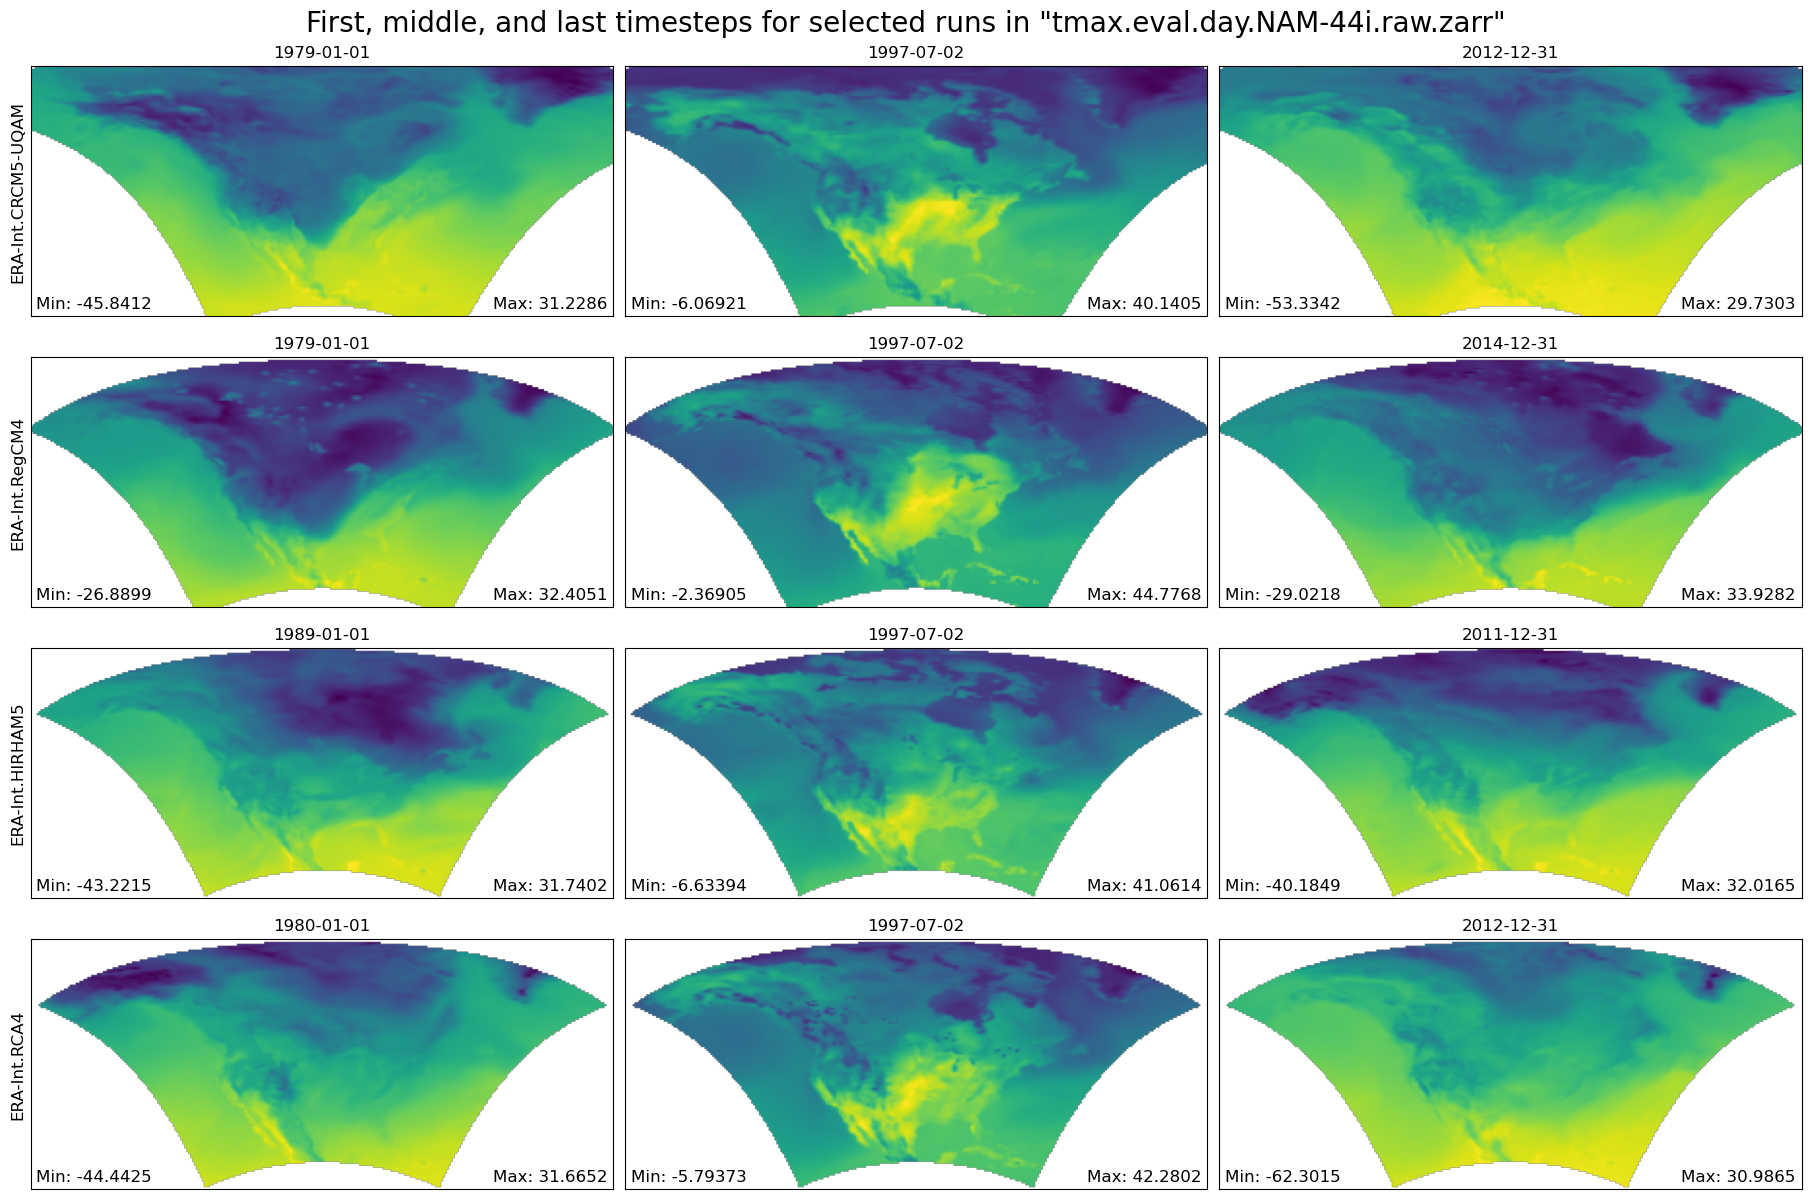

CPU times: user 4.8 s, sys: 430 ms, total: 5.23 s
Wall time: 1min 19s


In [7]:
%%time
plot_first_mid_last(ds, data_var, store_name)
plt.show()

In [8]:
client.close()
cluster.close()

---

## Summary

We opened NA-CORDEX daily maximum temperature directly from GDEX's OSDF Zarr store,
spun up a `LocalCluster`, and produced first/middle/last diagnostic maps across
several regional-model runs — a quick way to sanity-check a multi-member dataset.

### What's next?

Continue to the [CONUS404 workflow](conus404.ipynb) for another
high-resolution GDEX dataset.

## Resources and references

- [NA-CORDEX Visualization Cookbook (Project Pythia)](https://projectpythia.org/na-cordex-viz-cookbook/)
- [GDEX NA-CORDEX dataset (`d316010`)](https://gdex.ucar.edu/datasets/d316010/)
- [Original GDEX NA-CORDEX example](https://ncar.github.io/gdex-examples/na-cordex/)
- [xarray documentation](https://docs.xarray.dev)
- [Dask distributed](https://distributed.dask.org)